In [1]:
from fpdf import FPDF
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import matplotlib.transforms as mtransforms

In [6]:
# save FPDF() class into a 
# variable pdf
pdf = FPDF()
 
# Add a page
pdf.add_page()
 
# set style and size of font 
# that you want in the pdf
pdf.set_font("Arial", size = 15)
 
# create a cell
pdf.cell(200, 10, txt = "GeeksforGeeks", 
         ln = 1, align = 'C')
 
# add another cell
pdf.cell(200, 10, txt = "A Computer Science portal for geeks.",
         ln = 2, align = 'C')
 
# save the pdf with name .pdf
pdf.output("GFG.pdf")

''

In [15]:
class PDF(FPDF):
    def header(self):
        # Logo
        self.image('logounam.png', 10, 5, 20)
        # Arial bold 15
        self.set_font(family='Arial', style='B', size=15)
        # Move to the right
        self.cell(80)
        # Title
        self.cell(30, 10, 'Hyperparameter tuning report', 1, 0, 'C')
        # Line break
        self.ln(20)

    # Page footer
    def footer(self):
        # Position at 1.5 cm from bottom
        self.set_y(-15)
        # Arial italic 8
        self.set_font('Arial', 'I', 8)
        # Page number
        self.cell(0, 10, 'Page ' + str(self.page_no()) + '/{nb}', 0, 0, 'C')

# Instantiation of inherited class
pdf = PDF()
pdf.alias_nb_pages()
pdf.add_page()
pdf.set_font('Times', '', 12)
for i in range(1, 41):
    pdf.cell(0, 10, 'Printing line number ' + str(i), 0, 1)
pdf.output('tuto.pdf', 'F')

''

## Loading training curves

In [2]:
from scipy.io import loadmat,savemat

In [3]:
training_history = []
training_history.append(loadmat('History_Raw'))
training_history.append( loadmat('History_Amplitude'))
training_history.append( loadmat('History_Incidence'))
training_history.append(loadmat('History_Incidence_Amplitude'))

In [4]:
training_history_modlabel = []
training_history_modlabel.append(loadmat('History_Raw_Mod_Label'))
training_history_modlabel.append( loadmat('History_Amplitude_Mod_Label'))
training_history_modlabel.append( loadmat('History_Incidence_Mod_label'))
training_history_modlabel.append(loadmat('History_Incidence_Amplitude_Mod_Label_lr2'))

In [5]:
training_history[3]['loss'][0]

array([0.23223706, 0.13376451, 0.10126203, 0.08946525, 0.08383715,
       0.07817814, 0.0792738 , 0.07464422, 0.0753486 , 0.07322283,
       0.07289907, 0.07068147, 0.069679  , 0.07029984, 0.07096629,
       0.06717606, 0.06960969, 0.06803884, 0.06882583])

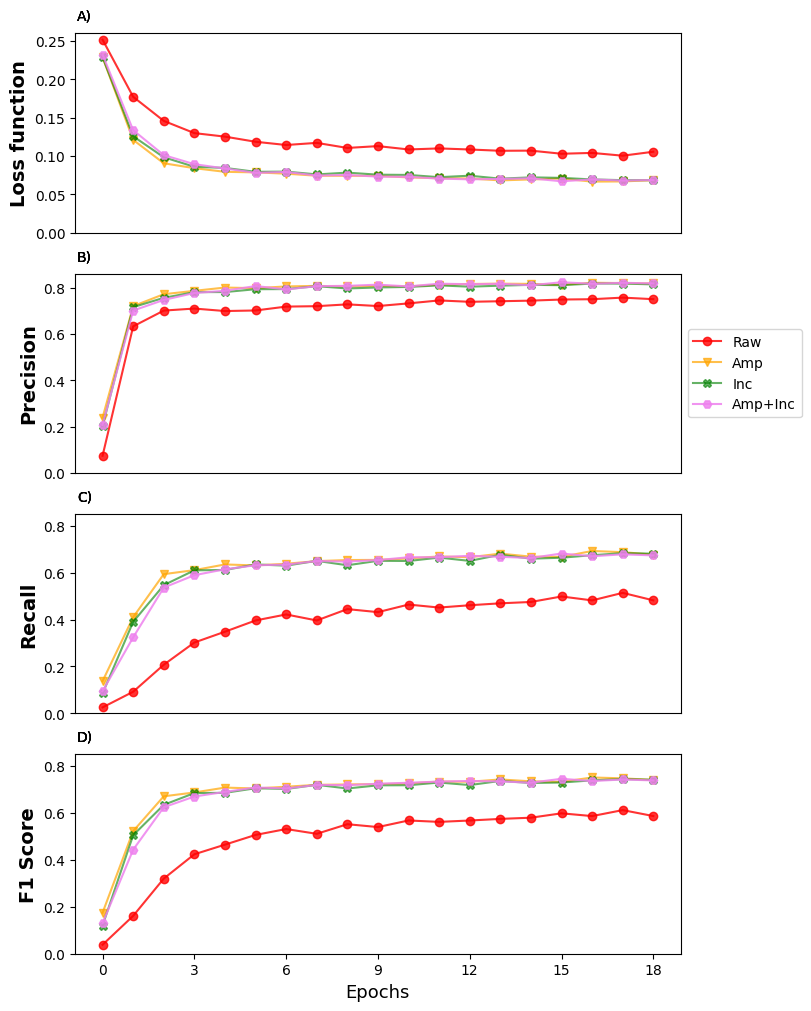

In [6]:
# mpl.rcParams['figure.figsize'] = (7,7)
fig,ax = plt.subplots(4,1,layout='constrained',figsize=(8,10))
#plt.suptitle(f'Training curves')
labels = ['Raw','Amp','Inc','Amp+Inc']
lab = ['A)','B)','C)','D)']
markers = ['o','v','X','H']
alphas = [0.8,0.7,0.6,0.85]
colors = ['red','orange','green','violet']

trans = mtransforms.ScaledTranslation(10/72, -5/72, fig.dpi_scale_trans)
for i in range(4):
    
    ax[0].plot(training_history[i]['loss'][0],label = labels[i],marker=markers[i],c=colors[i],alpha=alphas[i])
    #ax[0].plot(model_history.history['val_loss'],color='red',label = 'test')
    ax[0].grid(alpha=0.0)
    ax[0].set_ylabel('Loss function',fontsize=14,weight='bold')
    #ax[0].legend()
    ax[0].tick_params(left = True, right = False , labelleft = True ,
                    labelbottom = False, bottom = False, labeltop = False)
    ax[0].set_ylim(0.0,0.26)
    ax[0].text(-0.02, 1.1, lab[0],transform=ax[0].transAxes + trans)

    ax[1].plot(training_history[i]['precision'][0],label = labels[i],marker=markers[i],c=colors[i],alpha=alphas[i])
    #ax[2].plot(model_history.history['val_precision'],color='orange',label = 'test')
    ax[1].grid(alpha=0.0)
    ax[1].set_ylabel('Precision',fontsize=14,weight='bold')
    ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax[1].tick_params(left = True, right = False , labelleft = True ,
                    labelbottom = False, bottom = False, labeltop = False)
    ax[1].set_ylim(0.0,0.86)
    ax[1].text(-0.02, 1.1, lab[1],transform=ax[1].transAxes + trans)

    ax[2].plot(training_history[i]['recall'][0],label = labels[i],marker=markers[i],c=colors[i],alpha=alphas[i])
    #ax[3].plot(model_history.history['val_recall'],color='magenta',label = 'test')
    ax[2].grid(alpha=0.0)
    ax[2].set_ylabel('Recall',fontsize=14,weight='bold')
    #ax[3].set_xlabel('Epochs')
    #ax[3].legend()
    ax[2].tick_params(left = True, right = False , labelleft = True ,
                    labelbottom = False, bottom = False, labeltop = False)
    ax[2].set_ylim(0.0,0.85)
    ax[2].text(-0.02, 1.1, lab[2],transform=ax[2].transAxes + trans)
    
    ax[3].plot(training_history[i]['F1'][0],label = labels[i],marker=markers[i],c=colors[i],alpha=alphas[i])
    #ax[3].plot(model_history.history['val_recall'],color='magenta',label = 'test')
    ax[3].grid(alpha=0.0)
    ax[3].set_ylabel('F1 Score',fontsize=14,weight='bold')
    ax[3].set_xlabel('Epochs',fontsize=13)
    #ax[4].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax[3].set_xticks(np.arange(0, len(training_history[i]['F1'][0]+1), 3.0))
    ax[3].tick_params(left = True, right = False , labelleft = True ,
                    labelbottom = True, bottom = True, labeltop = False)
    ax[3].set_ylim(0.0,0.85)
    ax[3].text(-0.02, 1.1, lab[3],transform=ax[3].transAxes + trans)
fig.savefig('Training Curves Unet.png',dpi=200,bbox_inches='tight',pad_inches=0.05,transparent=False)

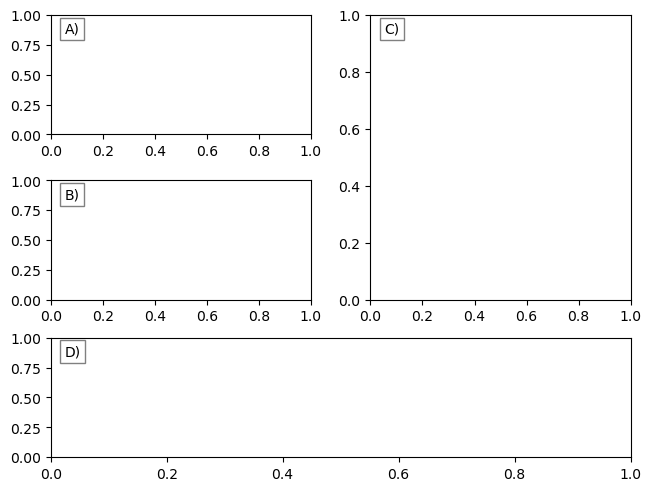

In [7]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

fig, axs = plt.subplot_mosaic([['A)', 'C)'], ['B)', 'C)'], ['D)', 'D)']],
                              layout='constrained')

for label, ax in axs.items():
    # label physical distance in and down:
    trans = mtransforms.ScaledTranslation(10/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', 
            bbox=dict(facecolor='1.0', edgecolor='grey', pad=3.0))#fontfamily='serif',

plt.show()

In [7]:
avg_mcc = np.zeros((4,2))
avg_mcc_modlabel = np.zeros((4,2))

for i in range(4):
    avg_mcc[i,0] = np.mean(training_history[i]['MCC_P'][0])
    avg_mcc[i,1] = np.mean(training_history[i]['MCC_S'][0])
    
    avg_mcc_modlabel[i,0] = np.mean(training_history_modlabel[i]['MCC_P'][0])
    avg_mcc_modlabel[i,1] = np.mean(training_history_modlabel[i]['MCC_S'][0])

In [8]:
avg_mcc_modlabel

array([[0.44546641, 0.35049367],
       [0.59247149, 0.6633322 ],
       [0.55209779, 0.69111145],
       [0.49368273, 0.36179143]])

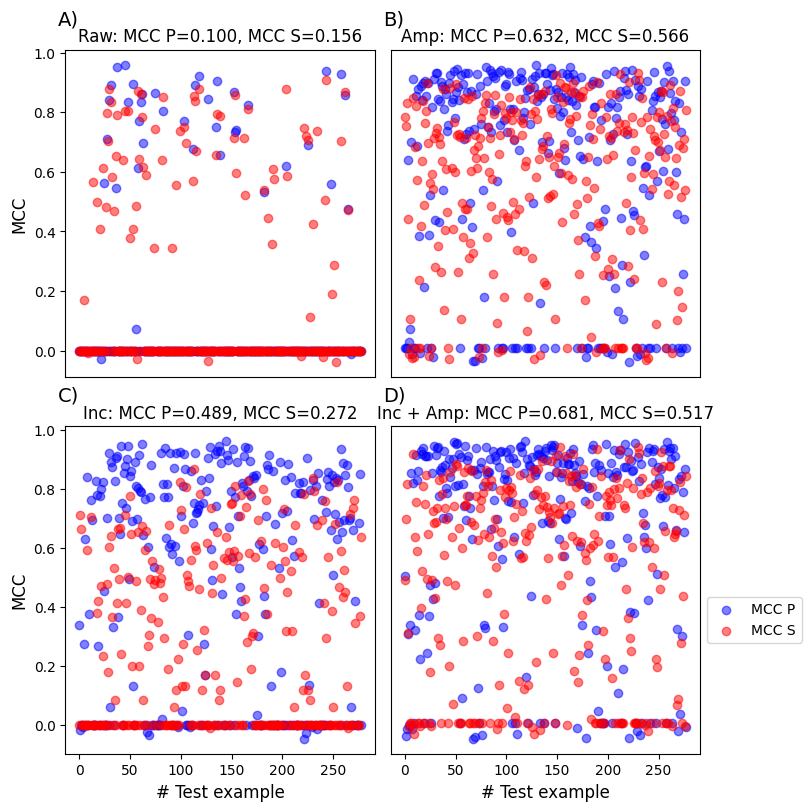

In [12]:
# Matthews Coefficient matrices
lab = ['A)','B)','C)','D)']
trans = mtransforms.ScaledTranslation(10/72, -5/72, fig.dpi_scale_trans)

fig,ax = plt.subplots(2,2,layout='constrained',figsize=(8,8))
x = np.arange(0,len(training_history[0]['MCC_P'][0]))

ax[0,0].scatter(x,training_history[0]['MCC_P'][0],color='blue',alpha=0.5,label='MCC P')
ax[0,0].scatter(x,training_history[0]['MCC_S'][0],color='red',alpha=0.5,label='MCC S')
ax[0,0].set_title(f'Raw: MCC P={avg_mcc[0,0]:.3f}, MCC S={avg_mcc[0,1]:.3f}',fontsize=12)
#ax[0,0].set_xlabel('# Test example',fontsize=9)
ax[0,0].set_ylabel('MCC',fontsize=12)
ax[0,0].tick_params(left = True, right = False , labelleft = True ,
                    labelbottom = False, bottom = False, labeltop = False)
ax[0,0].text(-0.07, 1.1, lab[0],transform=ax[0,0].transAxes + trans, fontsize=14)
#ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax[0,1].scatter(x,training_history[1]['MCC_P'][0],color='blue',alpha=0.5,label='MCC P')
ax[0,1].scatter(x,training_history[1]['MCC_S'][0],color='red',alpha=0.5,label='MCC S')
ax[0,1].set_title(f'Amp: MCC P={avg_mcc[1,0]:.3f}, MCC S={avg_mcc[1,1]:.3f}',fontsize=12)
#ax[0,1].set_xlabel('# Test example',fontsize=9)
#ax[0,1].set_ylabel('MCC',fontsize=9)
ax[0,1].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = False, bottom = False, labeltop = False)
ax[0,1].text(-0.07, 1.1, lab[1],transform=ax[0,1].transAxes + trans, fontsize=14)

ax[1,0].scatter(x,training_history[2]['MCC_P'][0],color='blue',alpha=0.5,label='MCC P')
ax[1,0].scatter(x,training_history[2]['MCC_S'][0],color='red',alpha=0.5,label='MCC S')
ax[1,0].set_title(f'Inc: MCC P={avg_mcc[2,0]:.3f}, MCC S={avg_mcc[2,1]:.3f}',fontsize=12)
ax[1,0].set_xlabel('# Test example',fontsize=12)
ax[1,0].set_ylabel('MCC',fontsize=12)
ax[1,0].text(-0.07, 1.1, lab[2],transform=ax[1,0].transAxes + trans, fontsize=14)

ax[1,1].scatter(x,training_history[3]['MCC_P'][0],color='blue',alpha=0.5,label='MCC P')
ax[1,1].scatter(x,training_history[3]['MCC_S'][0],color='red',alpha=0.5,label='MCC S')
ax[1,1].set_title(f'Inc + Amp: MCC P={avg_mcc[3,0]:.3f}, MCC S={avg_mcc[3,1]:.3f}',fontsize=12)
ax[1,1].set_xlabel('# Test example',fontsize=12)
ax[1,1].legend(loc='upper left', bbox_to_anchor=(1, 0.5))
ax[1,1].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = True, bottom = True, labeltop = False)
ax[1,1].text(-0.07, 1.1, lab[3],transform=ax[1,1].transAxes + trans, fontsize=14)
#ax[1,1].set_ylabel('MCC',fontsize=9)


fig.savefig('MCC Amplitude Mod Label.png',dpi=200,bbox_inches='tight',pad_inches=0.05,transparent=False)

In [42]:
training_history[i]['MCC_P'][0].shape

(278,)

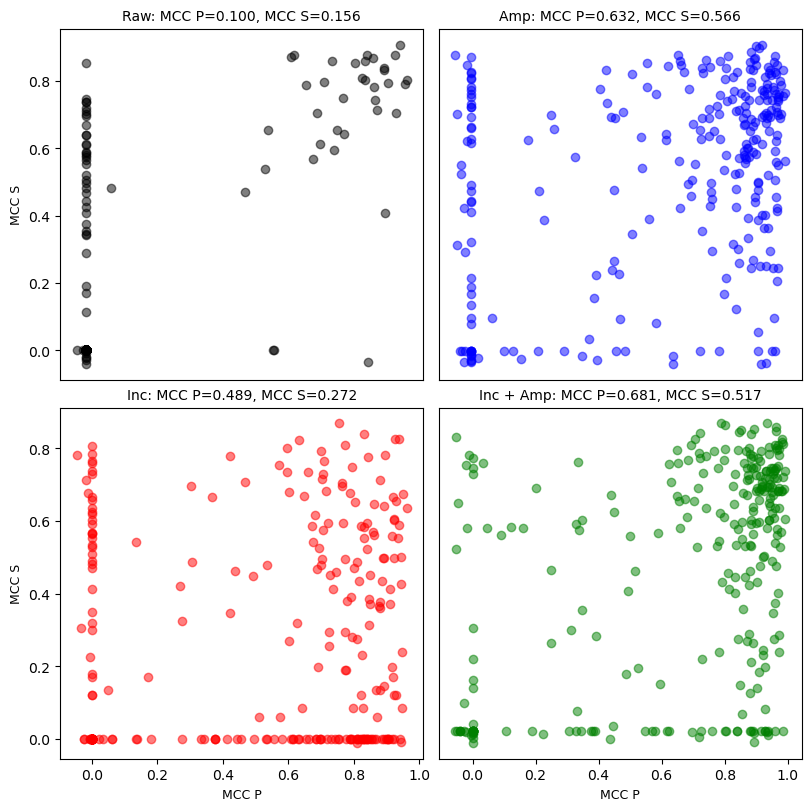

In [114]:
# Matthews Coefficient matrices
fig,ax = plt.subplots(2,2,layout='constrained',figsize=(8,8))
x = np.arange(0,len(training_history[0]['MCC_P'][0]))

ax[0,0].scatter(training_history[0]['MCC_P'][0],training_history[0]['MCC_S'][0],color='black',alpha=0.5)
ax[0,0].set_title(f'Raw: MCC P={avg_mcc[0,0]:.3f}, MCC S={avg_mcc[0,1]:.3f}',fontsize=10)
#ax[0,0].set_xlabel('# Test example',fontsize=9)
ax[0,0].set_ylabel('MCC S',fontsize=9)
ax[0,0].tick_params(left = True, right = False , labelleft = True ,
                    labelbottom = False, bottom = False, labeltop = False)

ax[0,1].scatter(training_history[1]['MCC_P'][0],training_history[1]['MCC_S'][0],color='blue',alpha=0.5)
ax[0,1].set_title(f'Amp: MCC P={avg_mcc[1,0]:.3f}, MCC S={avg_mcc[1,1]:.3f}',fontsize=10)
#ax[0,1].set_xlabel('# Test example',fontsize=9)
#ax[0,1].set_ylabel('MCC',fontsize=9)
ax[0,1].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = False, bottom = False, labeltop = False)

ax[1,0].scatter(training_history[2]['MCC_P'][0],training_history[2]['MCC_S'][0],color='red',alpha=0.5)
ax[1,0].set_title(f'Inc: MCC P={avg_mcc[2,0]:.3f}, MCC S={avg_mcc[2,1]:.3f}',fontsize=10)
ax[1,0].set_xlabel('MCC P',fontsize=9)
ax[1,0].set_ylabel('MCC S',fontsize=9)

ax[1,1].scatter(training_history[3]['MCC_P'][0],training_history[3]['MCC_S'][0],color='green',alpha=0.5)
ax[1,1].set_title(f'Inc + Amp: MCC P={avg_mcc[3,0]:.3f}, MCC S={avg_mcc[3,1]:.3f}',fontsize=10)
ax[1,1].set_xlabel('MCC P',fontsize=9)
#ax[1,1].legend(loc='upper left', bbox_to_anchor=(1, 0.5))
ax[1,1].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = True, bottom = True, labeltop = False)

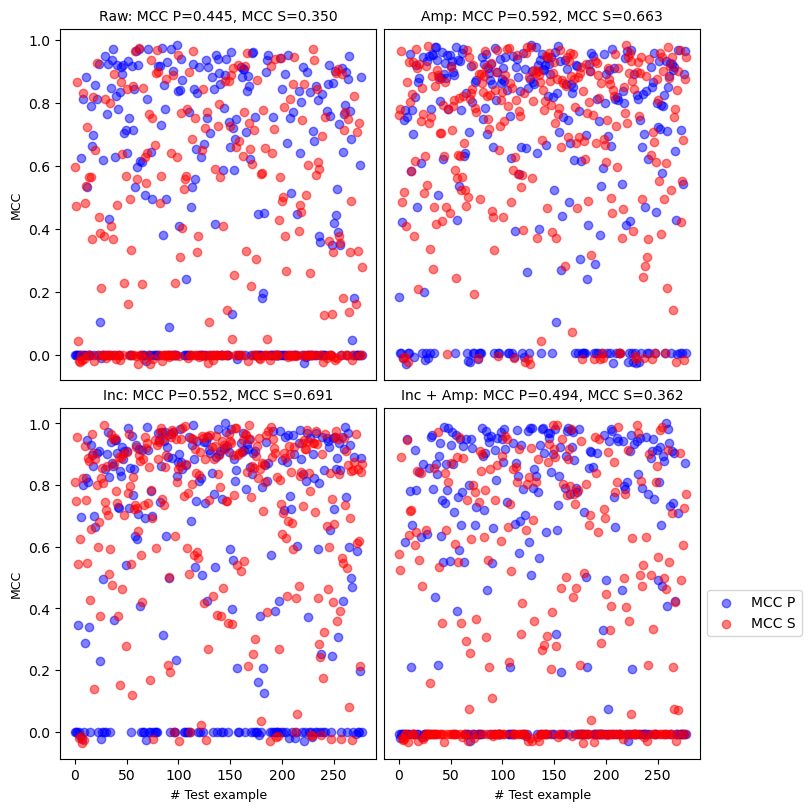

In [108]:
# Matthews Coefficient matrices
fig,ax = plt.subplots(2,2,layout='constrained',figsize=(8,8))
x = np.arange(0,len(training_history_modlabel[0]['MCC_P'][0]))

ax[0,0].scatter(x,training_history_modlabel[0]['MCC_P'][0],color='blue',alpha=0.5,label='MCC P')
ax[0,0].scatter(x,training_history_modlabel[0]['MCC_S'][0],color='red',alpha=0.5,label='MCC S')
ax[0,0].set_title(f'Raw: MCC P={avg_mcc_modlabel[0,0]:.3f}, MCC S={avg_mcc_modlabel[0,1]:.3f}',fontsize=10)
#ax[0,0].set_xlabel('# Test example',fontsize=9)
ax[0,0].set_ylabel('MCC',fontsize=9)
ax[0,0].tick_params(left = True, right = False , labelleft = True ,
                    labelbottom = False, bottom = False, labeltop = False)
#ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax[0,1].scatter(x,training_history_modlabel[1]['MCC_P'][0],color='blue',alpha=0.5,label='MCC P')
ax[0,1].scatter(x,training_history_modlabel[1]['MCC_S'][0],color='red',alpha=0.5,label='MCC S')
ax[0,1].set_title(f'Amp: MCC P={avg_mcc_modlabel[1,0]:.3f}, MCC S={avg_mcc_modlabel[1,1]:.3f}',fontsize=10)
#ax[0,1].set_xlabel('# Test example',fontsize=9)
#ax[0,1].set_ylabel('MCC',fontsize=9)
ax[0,1].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = False, bottom = False, labeltop = False)

ax[1,0].scatter(x,training_history_modlabel[2]['MCC_P'][0],color='blue',alpha=0.5,label='MCC P')
ax[1,0].scatter(x,training_history_modlabel[2]['MCC_S'][0],color='red',alpha=0.5,label='MCC S')
ax[1,0].set_title(f'Inc: MCC P={avg_mcc_modlabel[2,0]:.3f}, MCC S={avg_mcc_modlabel[2,1]:.3f}',fontsize=10)
ax[1,0].set_xlabel('# Test example',fontsize=9)
ax[1,0].set_ylabel('MCC',fontsize=9)

ax[1,1].scatter(x,training_history_modlabel[3]['MCC_P'][0],color='blue',alpha=0.5,label='MCC P')
ax[1,1].scatter(x,training_history_modlabel[3]['MCC_S'][0],color='red',alpha=0.5,label='MCC S')
ax[1,1].set_title(f'Inc + Amp: MCC P={avg_mcc_modlabel[3,0]:.3f}, MCC S={avg_mcc_modlabel[3,1]:.3f}',fontsize=10)
ax[1,1].set_xlabel('# Test example',fontsize=9)
ax[1,1].legend(loc='upper left', bbox_to_anchor=(1, 0.5))
ax[1,1].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = True, bottom = True, labeltop = False)
#ax[1,1].set_ylabel('MCC',fontsize=9)



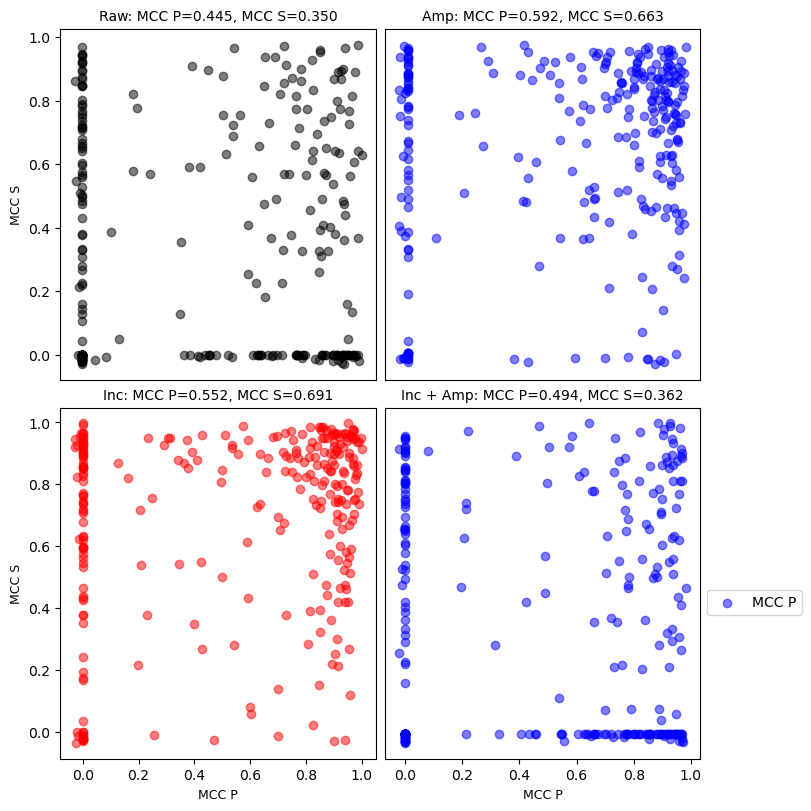

In [115]:
# Matthews Coefficient matrices
fig,ax = plt.subplots(2,2,layout='constrained',figsize=(8,8))
x = np.arange(0,len(training_history_modlabel[0]['MCC_P'][0]))

ax[0,0].scatter(training_history_modlabel[0]['MCC_P'][0],training_history_modlabel[0]['MCC_S'][0]
                ,color='black',alpha=0.5)
ax[0,0].set_title(f'Raw: MCC P={avg_mcc_modlabel[0,0]:.3f}, MCC S={avg_mcc_modlabel[0,1]:.3f}',fontsize=10)
ax[0,0].set_ylabel('MCC S',fontsize=9)
ax[0,0].tick_params(left = True, right = False , labelleft = True ,
                    labelbottom = False, bottom = False, labeltop = False)
#ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax[0,1].scatter(training_history_modlabel[1]['MCC_P'][0],training_history_modlabel[1]['MCC_S'][0]
                ,color='blue',alpha=0.5,label='MCC P')
ax[0,1].set_title(f'Amp: MCC P={avg_mcc_modlabel[1,0]:.3f}, MCC S={avg_mcc_modlabel[1,1]:.3f}',fontsize=10)
ax[0,1].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = False, bottom = False, labeltop = False)

ax[1,0].scatter(training_history_modlabel[2]['MCC_P'][0],training_history_modlabel[2]['MCC_S'][0]
                ,color='red',alpha=0.5,label='MCC P')
ax[1,0].set_title(f'Inc: MCC P={avg_mcc_modlabel[2,0]:.3f}, MCC S={avg_mcc_modlabel[2,1]:.3f}',fontsize=10)
ax[1,0].set_xlabel('MCC P',fontsize=9)
ax[1,0].set_ylabel('MCC S',fontsize=9)

ax[1,1].scatter(training_history_modlabel[3]['MCC_P'][0],training_history_modlabel[3]['MCC_S'][0]
                ,color='blue',alpha=0.5,label='MCC P')
ax[1,1].set_title(f'Inc + Amp: MCC P={avg_mcc_modlabel[3,0]:.3f}, MCC S={avg_mcc_modlabel[3,1]:.3f}',fontsize=10)
ax[1,1].set_xlabel('MCC P',fontsize=9)
ax[1,1].legend(loc='upper left', bbox_to_anchor=(1, 0.5))
ax[1,1].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = True, bottom = True, labeltop = False)